# kNN with cross-validation by choosing different hold-out years

In this notebook, for each pair `(pca_comp, n_nbr)`, we calculated the MAPE and R2 scores by choosing different years as holdout sets for cross validation. We printed the best combination in terms of mean MAPE and mean R2 scores over the cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from seaborn import set_style

set_style("whitegrid")

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("../data/final_dataframes/main_training_dataframe.csv")

In [ ]:
## Finds the days of a given year
def all_days_of_year(year):
    start_date = pd.Timestamp(year=year, month=1, day= 1)
    end_date = pd.Timestamp(year=year, month=12, day=31)
    return [x.strftime('%m-%d') for x in pd.date_range(start=start_date, end=end_date, freq= 'd')]

## Finds the true aggregate values of wind production per day of a given year
def true_aggregate_per_day(year):
    day_list = all_days_of_year(year)
    df_test = df[df.Year == year]
    aggregates = {}
    for day in day_list:
        df_day = df_test[df_test['MonthDay'] == day]
        aggregates[day] = sum(np.array(df_day.Wind))
    return(aggregates)

In [ ]:
## chooses all different combinations in the arrays pca_comps and n_nbrs to call the other functions 
## and returns the cv_mape and cv_r2 scores for combinations 
def pca_nbr_combinations(df):
    #pca_comps = [4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45]
    #n_nbrs = [4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50]
    pca_comps = [5,6]   ## checking small number of cases to manage runtime
    n_nbrs = [5, 7]
    comb_dic = {}   # contains list of (pca_comb, n_bdr) values
                    # format  0: (pca_comps[0], n_nbrs[0]), 1: (pca_comps[0], n_nbrs[1]) and so on
    cross_validation_mapes = []
    cross_validation_r2s = []
    cross_validation_maes = []
    preds_comb = []
    for i in range(len(pca_comps)):
        for j in range(len(n_nbrs)):
            comb_dic[len(n_nbrs)*i + j] = (pca_comps[i], n_nbrs[j])
            try:
                mapes ,r2s, mean_mae, preds = kNN_groupby_year_CV(df, pca_comps[i], n_nbrs[j])
                cross_validation_mapes.append(mapes)
                cross_validation_r2s.append(r2s)
                cross_validation_maes.append(mean_mae)
                preds_comb.append(preds)

                #displaying only the means and standard deviations across the 4 different years
                mean_mape = np.mean(mapes)
                std_mape = np.std(mapes)
                mean_r2 = np.mean(r2s)
                std_r2 = np.std(r2s) 
                print(f"Combination done {(pca_comps[i], n_nbrs[j])}: cv_mapes = {mean_mape:.3f} \u00B1 {std_mape:.3f}, cv_R2 = {mean_r2:.3f} \u00B1 {std_r2:.3f}.")
            except:
                print(f"Error in combination: {(pca_comps[i], n_nbrs[j])}")
    return comb_dic, preds_comb, cross_validation_mapes, cross_validation_r2s, cross_validation_maes

## returns the cv_mape and cv_r2 scores for a particular combination of (pca_comb, n_nbr)    
def kNN_groupby_year_CV(df,pca_comp,n_nbr):   
    mapes = [0]*4
    r2s = [0]*4
    preds = []
    mean_mae = 0
    for i , test_year in enumerate([2019,2020,2021,2022]):
        true_aggregates = true_aggregate_per_day(test_year)
        pred = kNN_by_test_year(df,pca_comp, n_nbr, test_year)
        try:
            mapes[i] = mean_absolute_percentage_error(y_true= [float(x) for x in true_aggregates.values()], y_pred= pred)
            r2s[i] = r2_score(y_true= [float(x) for x in true_aggregates.values()], y_pred= pred)
            mean_mae += mean_absolute_error( y_true= [float(x) for x in true_aggregates.values()], y_pred= pred )
            preds.append(pred)
        except:
            print(f"Error in test year: {test_year}")

    return mapes , r2s, mean_mae/4, preds 

## returns the predicted values of wind power per day for test_year for a given combination (pca_comp,n_nbr)
def kNN_by_test_year(df, pca_comp, n_nbr, test_year): 
    df_train = df[df['Year'] != test_year]
    df_test = df[df['Year'] == test_year]
    features = df.columns.drop(['Unnamed: 0', 'time', 'Year', 'MonthDay', 'Wind']) #extract the features

    pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components= pca_comp))])
    pipe.fit(df_train[features])

    pca_train = pipe.transform(df_train[features])
    pca_test = pipe.transform(df_test[features])


    knn = KNeighborsRegressor(n_neighbors=n_nbr)
    knn.fit(pca_train, df_train.Wind)
    pred = knn.predict(pca_test)

    no_days = len(all_days_of_year(test_year))
    pred_per_day = [sum(pred[24*i:24*(i+1)]) for i in range(no_days)]
    return pred_per_day

# Without speed cubed

In [5]:
# since wind direction is cylindrical variables, so we convert them to sine and cosine
new_cols = []

for i in range(1, 40):
    dir_col = f'wind_direction_10m_{i}'
    
    sin_col = np.sin(np.deg2rad(df[dir_col]))
    cos_col = np.cos(np.deg2rad(df[dir_col]))
    
    new_cols.append(pd.DataFrame({
        f'{dir_col}_sin': sin_col,
        f'{dir_col}_cos': cos_col
    }))

# Concatenate all new columns at once
df_new = pd.concat([df.drop(columns=[f'wind_direction_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

df_without_spd_cubed = df_new.copy()  # defragment

In [ ]:
## call the main function pca_nbr_combinations with the dataframe df_without_spd_cubed and store the values
comb_dic, preds_comb, cross_validation_mapes, cross_validation_r2s, cross_validation_maes = pca_nbr_combinations(df_without_spd_cubed)

Combination done (5, 5): cv_mapes = 0.238 ± 0.044, cv_R2 = 0.878 ± 0.015.
Combination done (5, 7): cv_mapes = 0.240 ± 0.045, cv_R2 = 0.879 ± 0.015.
Combination done (6, 5): cv_mapes = 0.211 ± 0.031, cv_R2 = 0.891 ± 0.015.
Combination done (6, 7): cv_mapes = 0.212 ± 0.033, cv_R2 = 0.892 ± 0.015.


In [7]:
## Finding the best combination in terms of MAPE and R2 scores and printing the errors
cv_mapes_means = [np.mean(x) for x in cross_validation_mapes]
cv_mapes_stds = [np.std(x) for x in cross_validation_mapes]
cv_r2s_means = [np.mean(x) for x in cross_validation_r2s]
cv_r2s_stds = [np.std(x) for x in cross_validation_r2s]
best_MAPE_mean_idx = cv_mapes_means.index(min(cv_mapes_means))
best_r2_mean_idx = cv_r2s_means.index(max(cv_r2s_means))

print(f"Best combination in terms of mean MAPE: pca = {comb_dic[best_MAPE_mean_idx][0]}, nbr = {comb_dic[best_MAPE_mean_idx][1]}, MAPE = {cv_mapes_means[best_MAPE_mean_idx]:.3f} \u00B1 {cv_mapes_stds[best_MAPE_mean_idx]:.3f}, R2 = {cv_r2s_means[best_MAPE_mean_idx]:.3f} \u00B1 {cv_r2s_stds[best_MAPE_mean_idx]:.3f} ")
print(f"Best combination in terms of mean R2 score: pca = {comb_dic[best_r2_mean_idx][0]}, nbr = {comb_dic[best_r2_mean_idx][1]}, MAPE = {cv_mapes_means[best_r2_mean_idx]:.3f} \u00B1 {cv_mapes_stds[best_r2_mean_idx]:.3f}, R2 = {cv_r2s_means[best_r2_mean_idx]:.3f} \u00B1 {cv_r2s_stds[best_r2_mean_idx]:.3f} ")

Best combination in terms of mean MAPE: pca = 6, nbr = 5, MAPE = 0.211 ± 0.031, R2 = 0.891 ± 0.015 
Best combination in terms of mean R2 score: pca = 6, nbr = 7, MAPE = 0.212 ± 0.033, R2 = 0.892 ± 0.015 


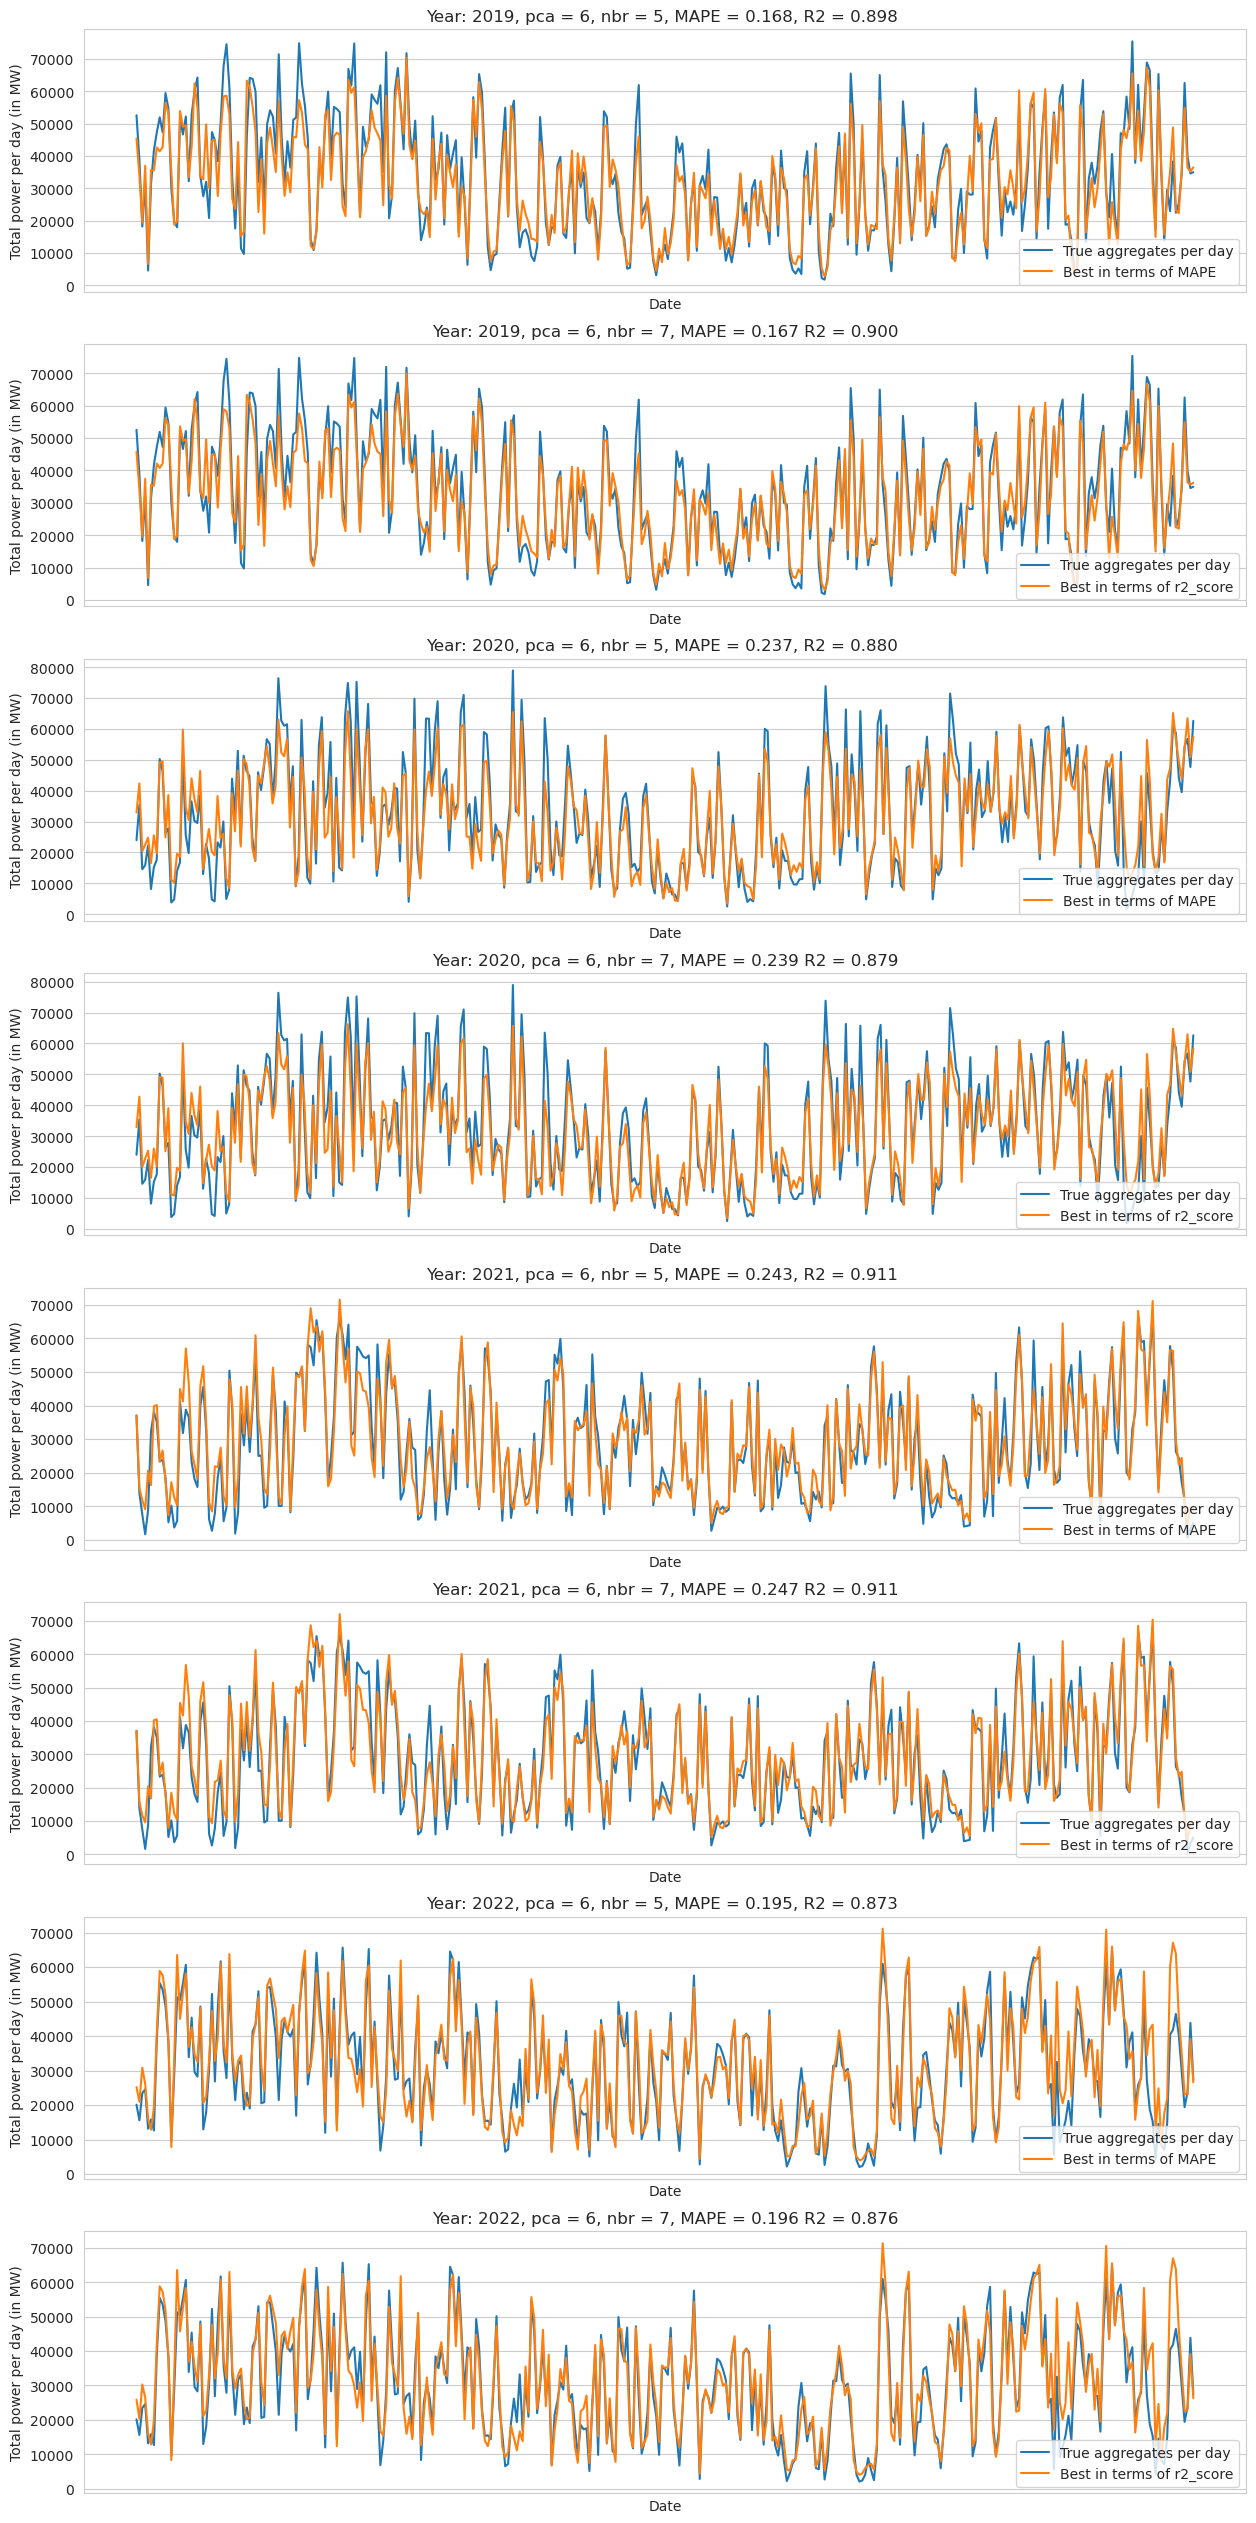

In [8]:
## Ploting for the best combinations (each for best cv_mape_mean and cv_r2_mean) for each year
fig, ax = plt.subplots(4*2, 1, figsize=(15, 8*4))
years = {0: 2019, 1:2020, 2:2021, 3:2022}
best_MAPE_preds = preds_comb[best_MAPE_mean_idx]
best_r2_preds = preds_comb[best_r2_mean_idx]

for i in range(4):
    test_year = years[i]
    days_list = all_days_of_year(test_year)
    true_aggregates = true_aggregate_per_day(test_year)
    ax[2*i].plot(days_list, true_aggregates.values(), label = 'True aggregates per day')
    ax[2*i+1].plot(days_list, true_aggregates.values(), label = 'True aggregates per day') 
   
    ax[2*i].plot(days_list, best_MAPE_preds[i], label = 'Best in terms of MAPE')
    ax[2*i].set_title(f"Year: {test_year}, pca = {comb_dic[best_MAPE_mean_idx][0]}, nbr = {comb_dic[best_MAPE_mean_idx][1]}, MAPE = {cross_validation_mapes[best_MAPE_mean_idx][i]:.3f}, R2 = {cross_validation_r2s[best_MAPE_mean_idx][i]:.3f} ")

    ax[2*i+1].plot(days_list, best_r2_preds[i], label = 'Best in terms of r2_score')
    ax[2*i+1].set_title(f"Year: {test_year}, pca = {comb_dic[best_r2_mean_idx][0]}, nbr = {comb_dic[best_r2_mean_idx][1]}, MAPE = {cross_validation_mapes[best_r2_mean_idx][i]:.3f} R2 = {cross_validation_r2s[best_r2_mean_idx][i]:.3f}")

for i in range(8):
    ax[i].legend(loc='lower right')
    ax[i].tick_params(axis='x', rotation = 45)
    ax[i].set_xticks([])
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Total power per day (in MW)')

plt.show()

# With speed cubed

In [9]:
# since theoretically the wind power depends on speed cubed, so we modify the columns as well
new_cols = []

for i in range(1, 40):
    spd_col = f'wind_speed_10m_{i}'
    cube_col = df[spd_col] ** 3
    
    new_cols.append(pd.DataFrame({
        f'{spd_col}_cubed': cube_col
    }))

# Concatenate all new columns at once
df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)])] + new_cols, axis=1)

df_speed_cubed = df_new.copy()  # defragment

In [ ]:
## call the main function pca_nbr_combinations with the dataframe df_speed_cubed and store the values
comb_dic, preds_comb, cross_validation_mapes, cross_validation_r2s, cross_validation_maes = pca_nbr_combinations(df_speed_cubed)

Combination done (5, 5): cv_mapes = 0.278 ± 0.052, cv_R2 = 0.866 ± 0.013.
Combination done (5, 7): cv_mapes = 0.283 ± 0.054, cv_R2 = 0.865 ± 0.014.
Combination done (6, 5): cv_mapes = 0.263 ± 0.050, cv_R2 = 0.874 ± 0.012.
Combination done (6, 7): cv_mapes = 0.268 ± 0.052, cv_R2 = 0.874 ± 0.012.


In [11]:
## Finding the best combination in terms of MAPE and R2 scores and printing the errors
cv_mapes_means = [np.mean(x) for x in cross_validation_mapes]
cv_mapes_stds = [np.std(x) for x in cross_validation_mapes]
cv_r2s_means = [np.mean(x) for x in cross_validation_r2s]
cv_r2s_stds = [np.std(x) for x in cross_validation_r2s]
best_MAPE_mean_idx = cv_mapes_means.index(min(cv_mapes_means))
best_r2_mean_idx = cv_r2s_means.index(max(cv_r2s_means))

print(f"Best combination in terms of mean MAPE: pca = {comb_dic[best_MAPE_mean_idx][0]}, nbr = {comb_dic[best_MAPE_mean_idx][1]}, MAPE = {cv_mapes_means[best_MAPE_mean_idx]:.3f} \u00B1 {cv_mapes_stds[best_MAPE_mean_idx]:.3f}, R2 = {cv_r2s_means[best_MAPE_mean_idx]:.3f} \u00B1 {cv_r2s_stds[best_MAPE_mean_idx]:.3f} ")
print(f"Best combination in terms of mean R2 score: pca = {comb_dic[best_r2_mean_idx][0]}, nbr = {comb_dic[best_r2_mean_idx][1]}, MAPE = {cv_mapes_means[best_r2_mean_idx]:.3f} \u00B1 {cv_mapes_stds[best_r2_mean_idx]:.3f}, R2 = {cv_r2s_means[best_r2_mean_idx]:.3f} \u00B1 {cv_r2s_stds[best_r2_mean_idx]:.3f} ")

Best combination in terms of mean MAPE: pca = 6, nbr = 5, MAPE = 0.263 ± 0.050, R2 = 0.874 ± 0.012 
Best combination in terms of mean R2 score: pca = 6, nbr = 5, MAPE = 0.263 ± 0.050, R2 = 0.874 ± 0.012 


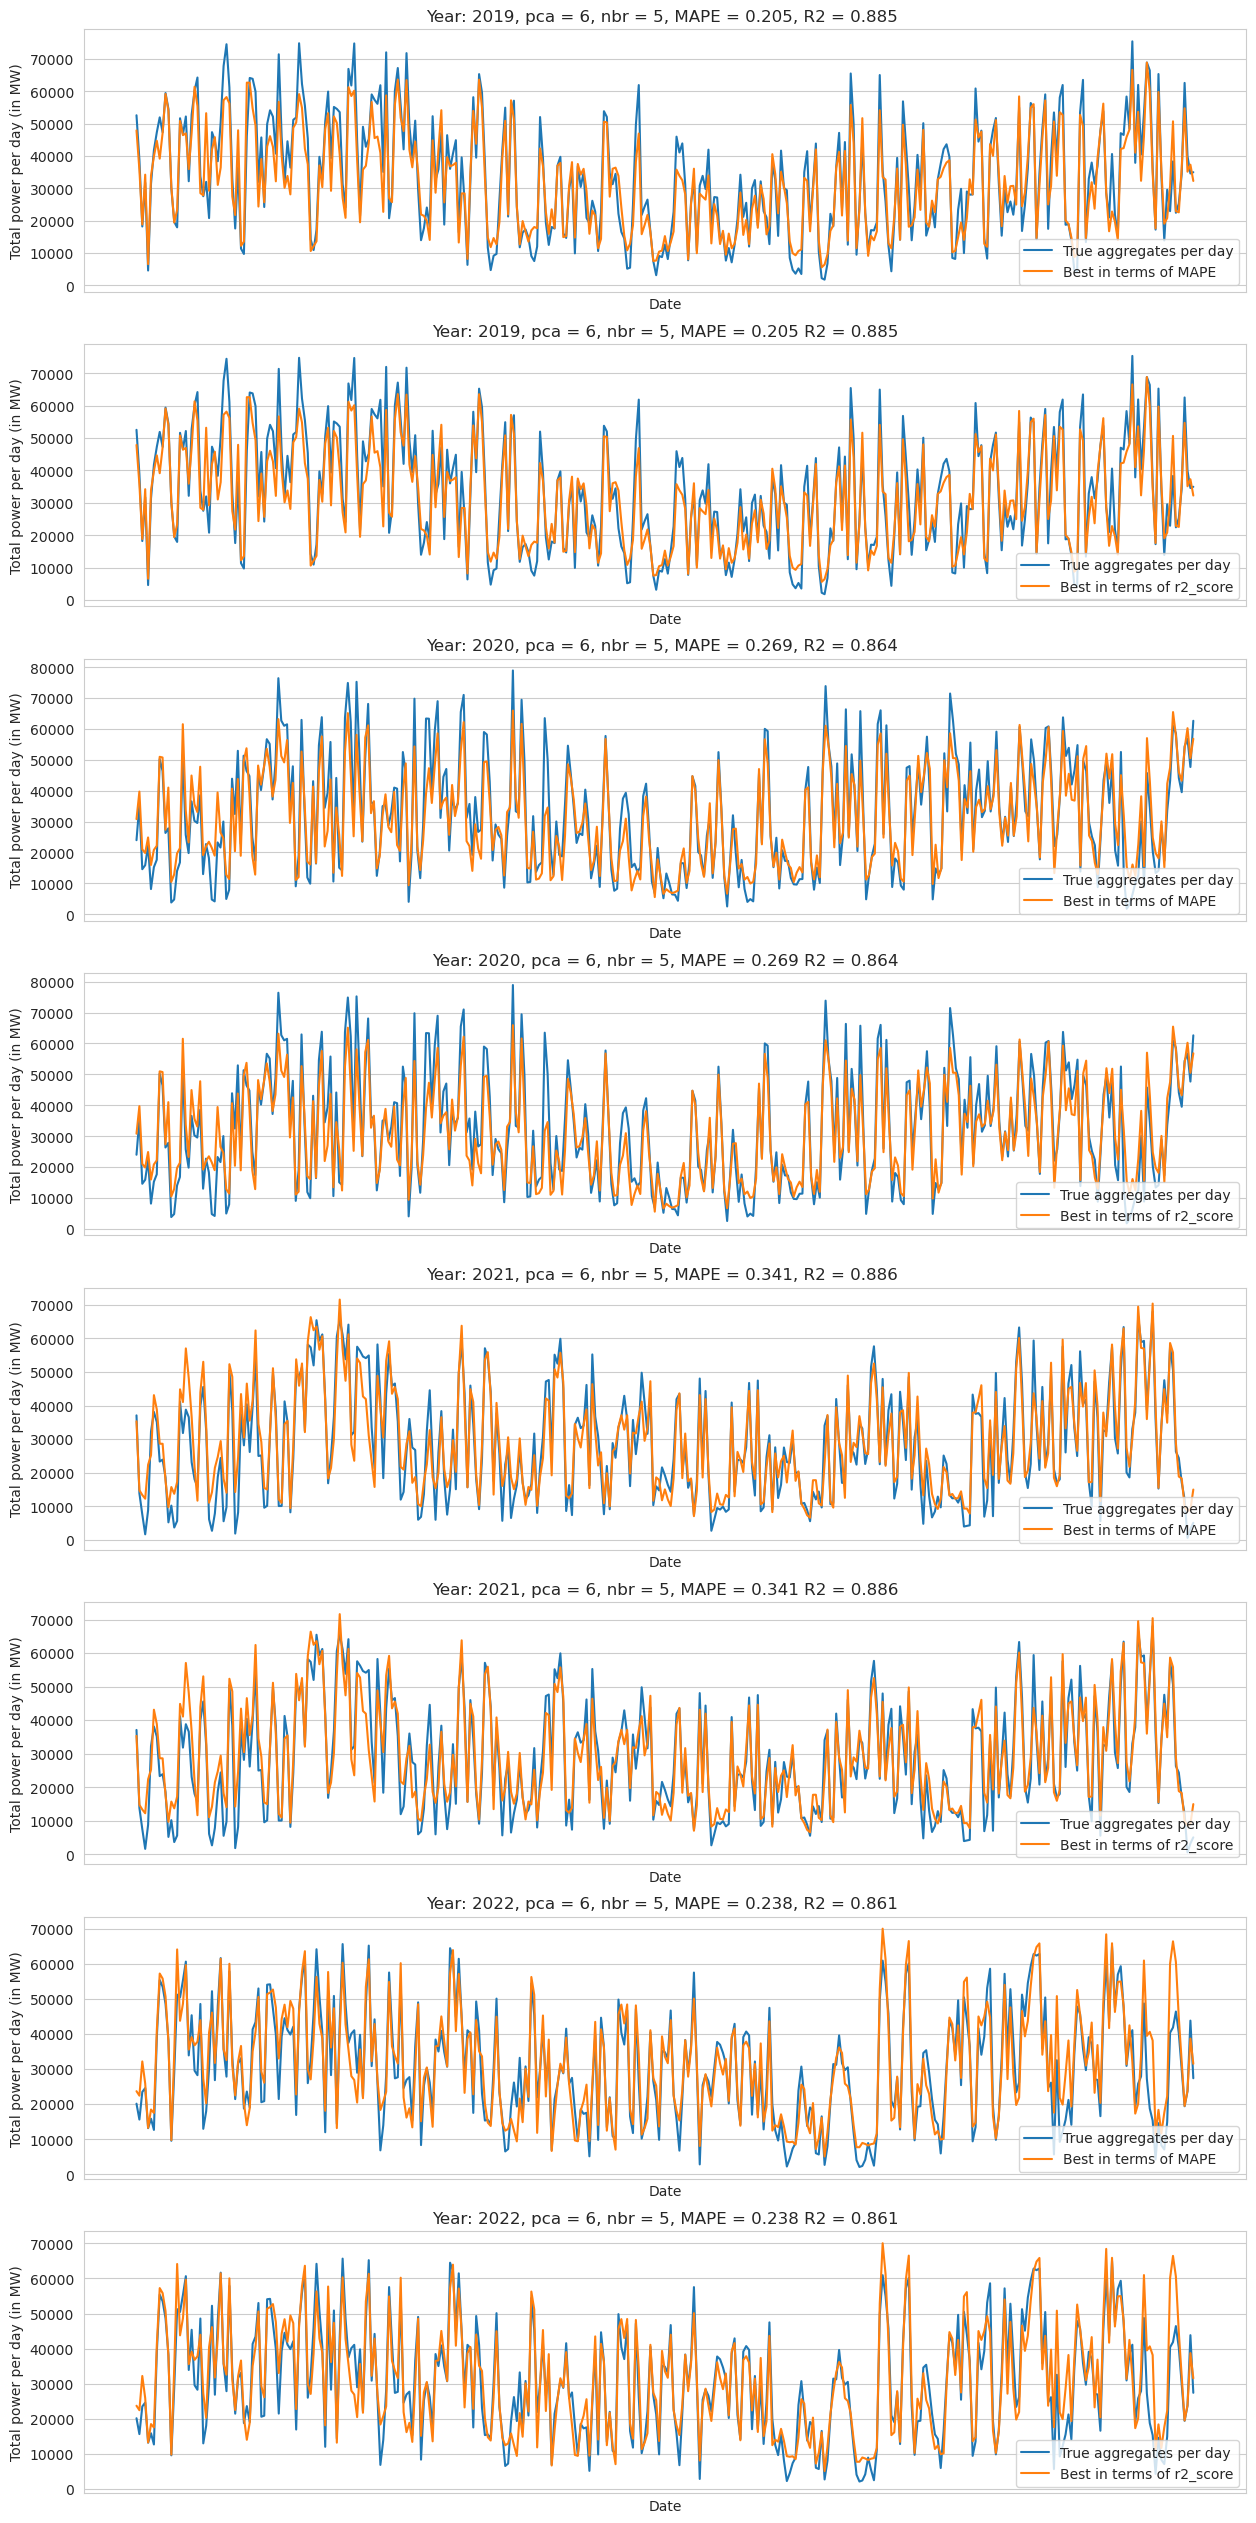

In [12]:
## Ploting for the best combinations (each for best cv_mape_mean and cv_r2_mean) for each year
fig, ax = plt.subplots(4*2, 1, figsize=(15, 8*4))
years = {0: 2019, 1:2020, 2:2021, 3:2022}
best_MAPE_preds = preds_comb[best_MAPE_mean_idx]
best_r2_preds = preds_comb[best_r2_mean_idx]

for i in range(4):
    test_year = years[i]
    days_list = all_days_of_year(test_year)
    true_aggregates = true_aggregate_per_day(test_year)
    ax[2*i].plot(days_list, true_aggregates.values(), label = 'True aggregates per day')
    ax[2*i+1].plot(days_list, true_aggregates.values(), label = 'True aggregates per day') 
   
    ax[2*i].plot(days_list, best_MAPE_preds[i], label = 'Best in terms of MAPE')
    ax[2*i].set_title(f"Year: {test_year}, pca = {comb_dic[best_MAPE_mean_idx][0]}, nbr = {comb_dic[best_MAPE_mean_idx][1]}, MAPE = {cross_validation_mapes[best_MAPE_mean_idx][i]:.3f}, R2 = {cross_validation_r2s[best_MAPE_mean_idx][i]:.3f} ")

    ax[2*i+1].plot(days_list, best_r2_preds[i], label = 'Best in terms of r2_score')
    ax[2*i+1].set_title(f"Year: {test_year}, pca = {comb_dic[best_r2_mean_idx][0]}, nbr = {comb_dic[best_r2_mean_idx][1]}, MAPE = {cross_validation_mapes[best_r2_mean_idx][i]:.3f} R2 = {cross_validation_r2s[best_r2_mean_idx][i]:.3f}")

for i in range(8):
    ax[i].legend(loc='lower right')
    ax[i].tick_params(axis='x', rotation = 45)
    ax[i].set_xticks([])
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Total power per day (in MW)')

plt.show()